In [1]:
import scipy.interpolate as spl
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
import scipy.integrate as spint
from scipy.optimize import curve_fit
import csv
import sys
sys.path.insert(1, '/Users/users/costa/Bulk/HC/project1/scripts')
import BayesLineFit_mod as blf

# Silk-Elmegreen (Boissier SFL) fitting

In [2]:
SFRD_file = '/Users/users/costa/Bulk/HC/project1/data/all_gals_Leroy08forHI_Frank16forH2.txt'

cols = ['gal', 'r_l08(kpc)', 'hi_l08(Msun/pc^2)', 'hi_err_l08(Msun/pc^2)', 'h2_f16_at_rl08(Msun/pc^2)', 'h2_err_f16_at_rl08(Msun/pc^2)', 'sfrd_l08(1e-4*Msun/yr/kpc^2)', 'sfrd_err_l08(1e-4*Msun/yr/kpc^2)']

sfrd_data = pd.read_csv(SFRD_file, sep=r"\s+", header=None, names=cols, comment="#", engine="python", dtype={"gal": "string"})

# print names of galaxies

sfrd_data["gal"] = sfrd_data["gal"].str.strip()
sfrd_gal_names = sfrd_data["gal"].unique().tolist()
print(sfrd_gal_names)

['DDO154', 'IC2574', 'NGC0925', 'NGC2403', 'NGC2841', 'NGC2976', 'NGC3198', 'NGC4736', 'NGC5055', 'NGC6946', 'NGC7331', 'NGC7793']


In [3]:
sfrd_data

,gal,r_l08(kpc),hi_l08(Msun/pc^2),hi_err_l08(Msun/pc^2),h2_f16_at_rl08(Msun/pc^2),h2_err_f16_at_rl08(Msun/pc^2),sfrd_l08(1e-4*Msun/yr/kpc^2),sfrd_err_l08(1e-4*Msun/yr/kpc^2)
0,DDO154,0.1,7.021416,0.673286,0.0,0.0,10.003113,2.116043
1,DDO154,0.3,6.925232,0.769470,0.0,0.0,9.426010,1.154205
2,DDO154,0.5,6.829048,0.673286,0.0,0.0,7.983253,1.250389
3,DDO154,0.7,6.540497,0.480919,0.0,0.0,6.348129,1.731308
4,DDO154,0.9,6.348129,0.384735,0.0,0.0,4.905373,1.538940
...,...,...,...,...,...,...,...,...
392,NGC7793,6.3,4.230207,0.571650,0.0,0.0,0.000000,1.143299
393,NGC7793,6.5,3.658558,0.457320,0.0,0.0,0.000000,1.143299
394,NGC7793,6.7,3.201238,0.342990,0.0,0.0,0.000000,1.143299
395,NGC7793,6.9,2.858248,0.342990,0.0,0.0,0.000000,1.143299


In [4]:
directory3 = "../data/allSFRprofs/"

rotcurves = {}  # galaxy -> DataFrame with R, Vrot, e_Vrot (and possibly old Σ)

for filename in os.listdir(directory3):
    if not filename.endswith(".txt"):
        continue

    filepath = os.path.join(directory3, filename)
    galaxy = os.path.splitext(filename)[0].split("_")[0].strip()

    df5 = pd.read_table(
        filepath,
        sep=r"\s+",
        engine="python",
        usecols=[
            "R[kpc]",
            "Vrot[km/s]",
            "e_Vrot[km/s]",
            "Sigma_gas[Msun/kpc2]",
            "e_Sigma_gas[Msun/kpc2]",
            "Sigma_SFR[Msun/yr/kpc2]",
            "e_Sigma_SFR[Msun/yr/kpc2]",
        ],
    )

    # clean + sort by radius
    df5 = df5.dropna(subset=["R[kpc]", "Vrot[km/s]"])
    df5 = df5.sort_values("R[kpc]")
    rotcurves[galaxy] = df5

In [5]:
# make sure galaxy names in sfrd_data are stripped
sfrd_data["gal"] = sfrd_data["gal"].str.strip()

def make_sigma_interp_log(R_data, Sigma_data, clamp_edges=False):
    """
    Log-space interpolator Σ(R) -> f(R_new), Σ in *positive* units.
    Outside the data range, holds log Σ flat at the edge values.
    
    If clamp_edges=True  : outside [R_min, R_max] keep log Σ fixed at edge values.
    If clamp_edges=False : outside [R_min, R_max] return NaN.
    
    Returns None if fewer than 2 valid points.
    """
    R_data  = np.asarray(R_data, float)
    Sigma_data = np.asarray(Sigma_data, float)

    mask = np.isfinite(R_data) & np.isfinite(Sigma_data) & (Sigma_data > 0)
    if mask.sum() < 2:
        return None

    R = R_data[mask]
    S = Sigma_data[mask]

    # sort by radius
    order = np.argsort(R)
    R = R[order]
    S = S[order]

    logS = np.log10(S)

    if clamp_edges:
        fill_value = (logS[0], logS[-1])
    else:
        # out of range -> NaN; these points can be dropped later
        fill_value = (np.nan, np.nan)
    
    f_log = interp1d(
        R, logS,
        kind="linear",
        bounds_error=False,
        fill_value=fill_value
    )

    def f(R_new):
        return 10.0**f_log(R_new)#np.clip(vals, 0.0, None)

    return f

rows = []

for gal, grp in sfrd_data.groupby("gal"):
    gal = str(gal)
    if gal not in rotcurves:
        # no rotation curve file for this galaxy → skip
        continue

    rc = rotcurves[gal]

    # OLD radii where we want everything
    R_old = rc["R[kpc]"].to_numpy(dtype=float)

    # NEW radii and corresponding Σ profiles
    r_new = grp["r_l08(kpc)"].to_numpy(dtype=float)
    order = np.argsort(r_new)
    r_new_sorted = r_new[order]

    hi_new      = grp["hi_l08(Msun/pc^2)"].to_numpy(dtype=float)[order]
    hi_err_new  = grp["hi_err_l08(Msun/pc^2)"].to_numpy(dtype=float)[order]
    h2_new      = grp["h2_f16_at_rl08(Msun/pc^2)"].to_numpy(dtype=float)[order]
    h2_err_new  = grp["h2_err_f16_at_rl08(Msun/pc^2)"].to_numpy(dtype=float)[order]
    sfr_new     = grp["sfrd_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(dtype=float)[order]
    sfr_err_new = grp["sfrd_err_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(dtype=float)[order]

    zero_mask = (sfr_new == 0.0)
    sfr_new[zero_mask] = np.nan
    sfr_err_new[zero_mask] = np.nan

    # interpolators for NEW HI, H2, SFR, and their errors
    f_hi      = make_sigma_interp_log(r_new_sorted, hi_new, clamp_edges=False)
    f_hi_err  = make_sigma_interp_log(r_new_sorted, hi_err_new, clamp_edges=False)
    f_h2      = make_sigma_interp_log(r_new_sorted, h2_new, clamp_edges=False)
    f_h2_err  = make_sigma_interp_log(r_new_sorted, h2_err_new, clamp_edges=False)
    f_sfr     = make_sigma_interp_log(r_new_sorted, sfr_new, clamp_edges=False)
    f_sfr_err = make_sigma_interp_log(r_new_sorted, sfr_err_new, clamp_edges=False)

    # if we don't have at least HI + H2 + SFR, skip this galaxy
    if f_hi is None or f_h2 is None or f_sfr is None: # 
        continue

    # evaluate at the OLD radii:
    hi_interp      = f_hi(R_old)
    hi_err_interp  = f_hi_err(R_old)   if f_hi_err  is not None else np.nan * R_old
    h2_interp      = f_h2(R_old)
    h2_err_interp  = f_h2_err(R_old)   if f_h2_err  is not None else np.nan * R_old
    sfr_interp     = f_sfr(R_old)
    sfr_err_interp = f_sfr_err(R_old)  if f_sfr_err is not None else np.nan * R_old

    df_comb = pd.DataFrame({
        "gal" : gal,
        "R[kpc]"       : R_old,
        "Vrot[km/s]"   : rc["Vrot[km/s]"].to_numpy(dtype=float),
        "e_Vrot[km/s]" : rc["e_Vrot[km/s]"].to_numpy(dtype=float),

        # NEW densities mapped onto the old radii:
        "hi_l08(Msun/pc^2)"             : hi_interp,
        "hi_err_l08(Msun/pc^2)"         : hi_err_interp,
        "h2_f16_at_rl08(Msun/pc^2)"     : h2_interp,
        "h2_err_f16_at_rl08(Msun/pc^2)" : h2_err_interp,
        "sfrd_l08(1e-4*Msun/yr/kpc^2)"  : sfr_interp,
        "sfrd_err_l08(1e-4*Msun/yr/kpc^2)" : sfr_err_interp,
    })

    rows.append(df_comb)

sfrd_on_rot = pd.concat(rows, ignore_index=True)
sfrd_on_rot.to_csv("../data/sfrd_with_interpolated_vrot.csv", index=False)

In [6]:
sfrd_on_rot

,gal,R[kpc],Vrot[km/s],e_Vrot[km/s],hi_l08(Msun/pc^2),hi_err_l08(Msun/pc^2),h2_f16_at_rl08(Msun/pc^2),h2_err_f16_at_rl08(Msun/pc^2),sfrd_l08(1e-4*Msun/yr/kpc^2),sfrd_err_l08(1e-4*Msun/yr/kpc^2)
0,NGC0925,0.200713,17.247000,3.720000,10.033235,0.652072,3.448329,0.763755,182.805941,30.986684
1,NGC0925,0.602138,17.248144,3.720145,10.759190,1.137569,2.909646,0.644445,128.262706,21.046063
2,NGC0925,1.003563,20.576380,4.141542,11.141178,1.099893,2.728299,0.604279,92.205551,13.420030
3,NGC0925,1.404989,26.579831,4.174999,10.883729,1.042285,2.552118,0.565257,67.041223,8.950803
4,NGC0925,1.806414,34.358248,2.655898,10.883361,1.042285,2.348633,0.520188,52.844810,9.126959
...,...,...,...,...,...,...,...,...,...,...
465,NGC7331,22.877000,241.574000,4.593000,3.080865,0.363622,0.008721,0.001882,NaN,NaN
466,NGC7331,23.305000,241.574000,4.593000,NaN,NaN,NaN,NaN,NaN,NaN
467,NGC7331,23.733000,241.574000,4.593000,NaN,NaN,NaN,NaN,NaN,NaN
468,NGC7331,24.160000,241.574000,4.593000,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
dwarf_sfrd_path = '../data/allSFRprofs/'
dwarf_list = ['DDO47', 'DDO50', 'DDO52', 'DDO87', 'DDO101', 'DDO126', 'DDO133', 'DDO168', 'NGC2366', 'WLM']
header_list = ["R[kpc]", "Vrot[km/s]", "e_Vrot[km/s]", "Sigma_gas[Msun/kpc2]", "e_Sigma_gas[Msun/kpc2]", "Sigma_SFR[Msun/yr/kpc2]", "e_Sigma_SFR[Msun/yr/kpc2]"]

dwarf_sfrd_dict = {}

for gal in dwarf_list:
    print(f"Processing galaxy: {gal}")
    # Load SFRD data
    dwarf_sfrd_file = os.path.join(dwarf_sfrd_path, f"{gal}_R_Vrot_SigmaGas_SigmaSFR.txt")
    dwarf_sfrd_data = pd.read_csv(dwarf_sfrd_file, sep='\s+')
    
    # save data for easy access, in a dictionary, with an array of arrays for each galaxy
    
    dwarf_sfrd_dict[gal] = {
        "R": dwarf_sfrd_data["R[kpc]"].values,
        "Vrot": dwarf_sfrd_data["Vrot[km/s]"].values,
        "e_Vrot": dwarf_sfrd_data["e_Vrot[km/s]"].values,
        "Sigma_gas": dwarf_sfrd_data["Sigma_gas[Msun/kpc2]"].values,
        "e_Sigma_gas": dwarf_sfrd_data["e_Sigma_gas[Msun/kpc2]"].values,
        "Sigma_SFR": dwarf_sfrd_data["Sigma_SFR[Msun/yr/kpc2]"].values,
        "e_Sigma_SFR": dwarf_sfrd_data["e_Sigma_SFR[Msun/yr/kpc2]"].values
    }

Processing galaxy: DDO47
Processing galaxy: DDO50
Processing galaxy: DDO52
Processing galaxy: DDO87
Processing galaxy: DDO101
Processing galaxy: DDO126
Processing galaxy: DDO133
Processing galaxy: DDO168
Processing galaxy: NGC2366
Processing galaxy: WLM


In [8]:
dwarf_sfrd_dict

{'DDO47': {'R': array([0.38, 0.76, 1.13, 1.51, 1.89, 2.27, 2.65, 3.03, 3.4 , 3.78, 4.16,
         4.54, 4.92, 5.29]),
  'Vrot': array([18.23, 26.91, 25.72, 29.66, 27.33, 28.88, 34.73, 39.85, 46.64,
         53.45, 57.87, 60.23, 62.27, 63.2 ]),
  'e_Vrot': array([3.23, 2.61, 3.79, 2.61, 2.49, 2.76, 2.3 , 2.37, 2.35, 3.15, 3.27,
         2.97, 3.45, 5.08]),
  'Sigma_gas': array([4290000., 3800000., 3660000., 3800000., 3900000., 3770000.,
         3980000., 3870000., 3440000., 2980000., 2740000., 2490000.,
         2110000., 1660000.]),
  'e_Sigma_gas': array([1120000., 1180000., 1220000., 1580000., 1740000., 1320000.,
         1070000., 1340000., 1300000., 1070000., 1040000., 1310000.,
         1310000., 1160000.]),
  'Sigma_SFR': array([1.75270104e-03, 8.88194895e-04, 5.28668736e-04, 4.78456383e-04,
         3.95292383e-04, 3.24353130e-04, 2.75238547e-04, 2.29561880e-04,
         1.67080992e-04, 1.35696899e-04, 1.23184305e-04, 1.08744262e-04,
         5.42649058e-05, 3.98974284e-05]),
 

In [9]:
# add dwarf data from dwarf_sfrd_dict to the main sfrd_on_rot DataFrame
for gal in dwarf_list:
    if gal not in sfrd_on_rot['gal'].values:
        # Create a DataFrame for the dwarf galaxy data
        df_dwarf = pd.DataFrame({
            'gal': gal,
            'R[kpc]': dwarf_sfrd_dict[gal]['R'],
            'Vrot[km/s]': dwarf_sfrd_dict[gal]['Vrot'],
            'e_Vrot[km/s]': dwarf_sfrd_dict[gal]['e_Vrot'],
            'hi_l08(Msun/pc^2)': 1.4*dwarf_sfrd_dict[gal]['Sigma_gas']*1e-6,
            'hi_err_l08(Msun/pc^2)': 1.4*dwarf_sfrd_dict[gal]['e_Sigma_gas']*1e-6,
            'h2_f16_at_rl08(Msun/pc^2)': 0,  # No H2 data for dwarfs
            'h2_err_f16_at_rl08(Msun/pc^2)': 0,  # No H2 data for dwarfs
            'sfrd_l08(1e-4*Msun/yr/kpc^2)': dwarf_sfrd_dict[gal]['Sigma_SFR'],
            'sfrd_err_l08(1e-4*Msun/yr/kpc^2)': dwarf_sfrd_dict[gal]['e_Sigma_SFR']
        })
        
        # Append the dwarf galaxy data to the main DataFrame
        sfrd_on_rot = pd.concat([sfrd_on_rot, df_dwarf], ignore_index=True)
        sfrd_data = pd.concat([sfrd_data, df_dwarf], ignore_index=True)

In [10]:
sfrd_on_rot

,gal,R[kpc],Vrot[km/s],e_Vrot[km/s],hi_l08(Msun/pc^2),hi_err_l08(Msun/pc^2),h2_f16_at_rl08(Msun/pc^2),h2_err_f16_at_rl08(Msun/pc^2),sfrd_l08(1e-4*Msun/yr/kpc^2),sfrd_err_l08(1e-4*Msun/yr/kpc^2)
0,NGC0925,0.200713,17.247000,3.720000,10.033235,0.652072,3.448329,0.763755,182.805941,30.986684
1,NGC0925,0.602138,17.248144,3.720145,10.759190,1.137569,2.909646,0.644445,128.262706,21.046063
2,NGC0925,1.003563,20.576380,4.141542,11.141178,1.099893,2.728299,0.604279,92.205551,13.420030
3,NGC0925,1.404989,26.579831,4.174999,10.883729,1.042285,2.552118,0.565257,67.041223,8.950803
4,NGC0925,1.806414,34.358248,2.655898,10.883361,1.042285,2.348633,0.520188,52.844810,9.126959
...,...,...,...,...,...,...,...,...,...,...
629,WLM,2.390000,34.320000,2.940000,1.484000,0.602000,0.000000,0.000000,0.000000,0.000000
630,WLM,2.510000,34.350000,3.260000,1.288000,0.602000,0.000000,0.000000,0.000000,0.000000
631,WLM,2.630000,34.940000,3.250000,1.106000,0.588000,0.000000,0.000000,0.000000,0.000000
632,WLM,2.750000,35.390000,3.380000,0.966000,0.560000,0.000000,0.000000,0.000000,0.000000


In [11]:
np.unique(sfrd_on_rot['gal'])

array(['DDO101', 'DDO126', 'DDO133', 'DDO168', 'DDO47', 'DDO50', 'DDO52',
       'DDO87', 'NGC0925', 'NGC2366', 'NGC2403', 'NGC2841', 'NGC2976',
       'NGC3198', 'NGC4736', 'NGC5055', 'NGC6946', 'NGC7331', 'WLM'],
      dtype=object)

In [12]:
v_sesfl = sfrd_on_rot["Vrot[km/s]"].to_numpy(float) # in km/s
v_err_sesfl = sfrd_on_rot["e_Vrot[km/s]"].to_numpy(float) # in km/s
r_sesfl = sfrd_on_rot["R[kpc]"].to_numpy(float) # in kpc

sigma_hi = sfrd_on_rot["hi_l08(Msun/pc^2)"].to_numpy(float) # in Msun/pc^2
sigma_h2 = sfrd_on_rot["h2_f16_at_rl08(Msun/pc^2)"].to_numpy(float) # in Msun/pc^2

sigma_hi_err = sfrd_on_rot["hi_err_l08(Msun/pc^2)"].to_numpy(float) # in Msun/pc^2
sigma_h2_err = sfrd_on_rot["h2_err_f16_at_rl08(Msun/pc^2)"].to_numpy(float) # in Msun/pc^2

sigma_gas_sesfl = (sigma_hi + sigma_h2) * 1e6 # Msun/kpc^2
sigma_gas_err_sesfl = np.sqrt(sigma_hi_err**2 + sigma_h2_err**2)*1e6 # Msun/kpc^2

# multiply by 1e-4 for all galaxies except for the dwarfs
mask_dwarfs = sfrd_on_rot['gal'].isin(dwarf_list)
sigma_sfr_sesfl = sfrd_on_rot["sfrd_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(float)
sigma_sfr_sesfl[~mask_dwarfs] *= 1e-4
sigma_sfr_err_sesfl = sfrd_on_rot["sfrd_err_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(float)
sigma_sfr_err_sesfl[~mask_dwarfs] *= 1e-4

omega_sesfl = (v_sesfl/r_sesfl)*1.022e-9 # in units of yr^-1 if r_sesfl is in kpc and v_sesfl in km/s
omega_err_sesfl = (v_err_sesfl/r_sesfl)*1.022e-9

In [13]:
KSL_only_sigma_hi = sfrd_data["hi_l08(Msun/pc^2)"].to_numpy(float) # in Msun/pc^2
KSL_only_sigma_h2 = sfrd_data["h2_f16_at_rl08(Msun/pc^2)"].to_numpy(float) # in Msun/pc^2

KSL_only_sigma_hi_err = sfrd_data["hi_err_l08(Msun/pc^2)"].to_numpy(float) # in Msun/pc^2
KSL_only_sigma_h2_err = sfrd_data["h2_err_f16_at_rl08(Msun/pc^2)"].to_numpy(float) # in Msun/pc^2

KSL_only_sigma_gas = (KSL_only_sigma_hi + KSL_only_sigma_h2) * 1e6 # Msun/kpc^2
KSL_only_sigma_gas_err = np.sqrt(KSL_only_sigma_hi_err**2 + KSL_only_sigma_h2_err**2)*1e6 # Msun/kpc^2

mask_dwarfs = sfrd_data['gal'].isin(dwarf_list)
KSL_only_sigma_sfr = sfrd_data["sfrd_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(float) # in Msun/yr/kpc^2
KSL_only_sigma_sfr[~mask_dwarfs] *= 1e-4
KSL_only_sigma_sfr_err = sfrd_data["sfrd_err_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(float) # in Msun/yr/kpc^2
KSL_only_sigma_sfr_err[~mask_dwarfs] *= 1e-4

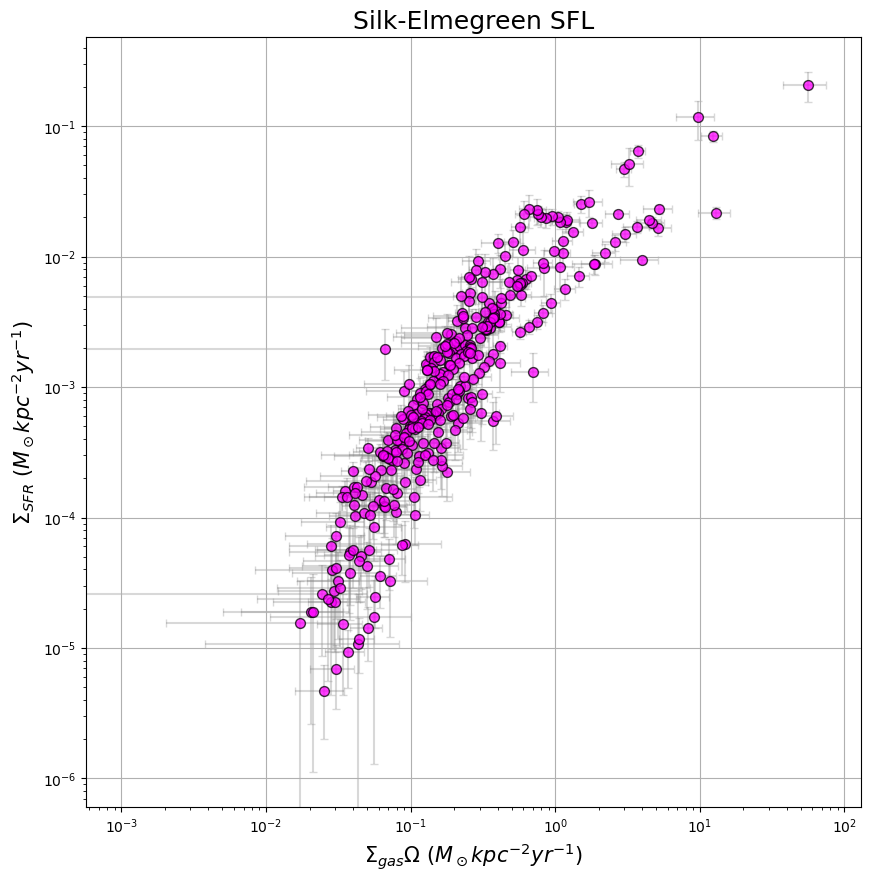

In [14]:
fig = figure(figsize=(10,10), facecolor='w')
frame = fig.add_subplot(1,1,1)
# plot each galaxy with a different color, make sure all colors are different
# for i, gal in enumerate(np.unique(sfrd_on_rot['gal'])):
#     mask = sfrd_on_rot['gal'] == gal
#     frame.scatter(sigma_gas_sesfl[mask]*omega_sesfl[mask], sigma_sfr_sesfl[mask], color=plt.cm.tab20(i), edgecolor='k', s=50, label=gal)
#     frame.errorbar(sigma_gas_sesfl[mask]*omega_sesfl[mask], sigma_sfr_sesfl[mask], xerr=sigma_gas_sesfl[mask]*omega_sesfl[mask]*np.sqrt((sigma_gas_err_sesfl[mask]/sigma_gas_sesfl[mask])**2 + (omega_err_sesfl[mask]/omega_sesfl[mask])**2), yerr=sigma_sfr_err_sesfl[mask], fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=1)
frame.scatter(sigma_gas_sesfl*omega_sesfl, sigma_sfr_sesfl, color="magenta", edgecolor='k', s=50, zorder=2, alpha=.75)
frame.errorbar(sigma_gas_sesfl*omega_sesfl, sigma_sfr_sesfl, xerr=sigma_gas_sesfl*omega_sesfl*np.sqrt((sigma_gas_err_sesfl/sigma_gas_sesfl)**2 + (omega_err_sesfl/omega_sesfl)**2), yerr=sigma_sfr_err_sesfl, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=1)
frame.set_xscale('log')
frame.set_yscale('log')
frame.set_title(r"Silk-Elmegreen SFL", fontsize = 18)
frame.set_xlabel(r"$\Sigma_{gas}\Omega$ $(M_\odot kpc^{-2} yr^{-1})$", fontsize = 15)
frame.set_ylabel(r"$\Sigma_{SFR}$ $(M_\odot kpc^{-2} yr^{-1})$", fontsize = 15)
#frame.legend()
frame.grid(zorder=0)
show()

In [15]:
mask = np.isfinite(sigma_gas_sesfl) & np.isfinite(sigma_sfr_sesfl) & np.isfinite(omega_sesfl) & (sigma_sfr_sesfl != 0) & (sigma_sfr_err_sesfl != 0)
masked_sigma_sfr_sesfl = sigma_sfr_sesfl[mask]*1e-6 #turn it from kpc^-2 to pc^-2
masked_sigma_sfr_err_sesfl = sigma_sfr_err_sesfl[mask]*1e-6
masked_sigma_gas_sesfl = sigma_gas_sesfl[mask]*1e-6
masked_sigma_gas_err_sesfl = sigma_gas_err_sesfl[mask]*1e-6
masked_omega_sesfl = omega_sesfl[mask]
masked_omega_err_sesfl = omega_err_sesfl[mask]

mask_KSL_only = np.isfinite(KSL_only_sigma_gas) & (KSL_only_sigma_gas != 0) & np.isfinite(KSL_only_sigma_sfr) & (KSL_only_sigma_sfr != 0) & (KSL_only_sigma_sfr_err != 0) & np.isfinite(KSL_only_sigma_gas_err) & (KSL_only_sigma_gas_err != 0) & np.isfinite(KSL_only_sigma_sfr_err)
masked_KSL_only_sigma_sfr = KSL_only_sigma_sfr[mask_KSL_only]*1e-6
masked_KSL_only_sigma_sfr_err = KSL_only_sigma_sfr_err[mask_KSL_only]*1e-6
masked_KSL_only_sigma_gas = KSL_only_sigma_gas[mask_KSL_only]*1e-6
masked_KSL_only_sigma_gas_err = KSL_only_sigma_gas_err[mask_KSL_only]*1e-6

In [16]:
def fit_se(x, a, n):
    return a * (x**n)

x_combined = np.array([masked_sigma_gas_sesfl, masked_omega_sesfl])

popt, pcov = curve_fit(fit_se, masked_sigma_gas_sesfl, masked_sigma_sfr_sesfl/masked_omega_sesfl, p0=[4.5e-6, 2])
#, sigma=(masked_sigma_sfr_sesfl/masked_omega_sesfl*np.sqrt((masked_sigma_sfr_err_sesfl/masked_sigma_sfr_sesfl)**2 + (masked_omega_err_sesfl/masked_omega_sesfl)**2))
a_sesfl, n_sesfl = popt
print(a_sesfl, n_sesfl)

0.018605722123202946 0.7144774552007029


In [17]:
NGC5055 = pd.read_table("../data/allSFRprofs/NGC5055_R_Vrot_SigmaGas_SigmaSFR.txt", sep=" ", usecols=["R[kpc]", "Vrot[km/s]", "e_Vrot[km/s]", "Sigma_gas[Msun/kpc2]", "e_Sigma_gas[Msun/kpc2]", "Sigma_SFR[Msun/yr/kpc2]", "e_Sigma_SFR[Msun/yr/kpc2]"])

NGC5055_r = pd.to_numeric(NGC5055['R[kpc]'], errors='coerce')
NGC5055_vrot = pd.to_numeric(NGC5055['Vrot[km/s]'], errors='coerce')
NGC5055_evrot = pd.to_numeric(NGC5055['e_Vrot[km/s]'], errors='coerce')
NGC5055_sgas = pd.to_numeric(NGC5055['Sigma_gas[Msun/kpc2]'], errors='coerce')*1e-6
NGC5055_esgas = pd.to_numeric(NGC5055['e_Sigma_gas[Msun/kpc2]'], errors='coerce')*1e-6
NGC5055_ssfr = pd.to_numeric(NGC5055['Sigma_SFR[Msun/yr/kpc2]'], errors='coerce')*1e-6
NGC5055_essfr = pd.to_numeric(NGC5055['e_Sigma_SFR[Msun/yr/kpc2]'], errors='coerce')*1e-6

NGC5055_omega = (NGC5055_vrot/NGC5055_r)*1.022e-9
NGC5055_eomega = (NGC5055_evrot/NGC5055_r)*1.022e-9

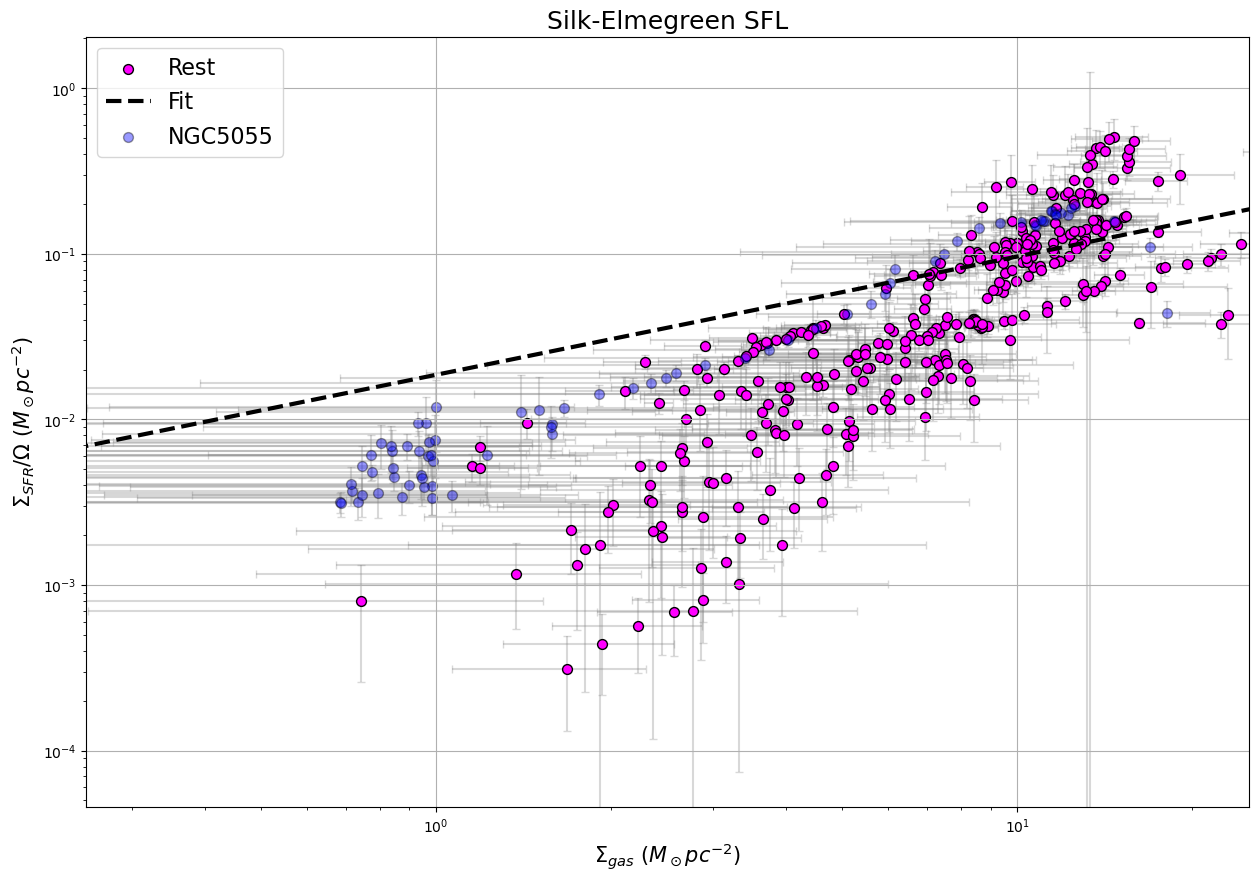

In [18]:
sigma_gas_lin = np.linspace(2e-1, 3e1, 100)

fig = figure(figsize=(15,10), facecolor='w')
frame = fig.add_subplot(1,1,1)
frame.scatter(masked_sigma_gas_sesfl, masked_sigma_sfr_sesfl/masked_omega_sesfl, color="magenta", edgecolor='k', s=50, label="Rest")
frame.errorbar(masked_sigma_gas_sesfl, masked_sigma_sfr_sesfl/masked_omega_sesfl, xerr=masked_sigma_gas_err_sesfl, yerr=masked_sigma_sfr_sesfl/masked_omega_sesfl*np.sqrt((masked_sigma_sfr_err_sesfl/masked_sigma_sfr_sesfl)**2 + (masked_omega_err_sesfl/masked_omega_sesfl)**2), fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
frame.plot(sigma_gas_lin, fit_se(sigma_gas_lin, a_sesfl, n_sesfl), color="k", lw=3, ls="dashed", label="Fit")
frame.scatter(NGC5055_sgas, NGC5055_ssfr/NGC5055_omega, color="blue", edgecolor='k', s=50, alpha=0.4, label="NGC5055")
frame.errorbar(NGC5055_sgas, NGC5055_ssfr/NGC5055_omega, xerr=NGC5055_esgas, yerr=NGC5055_ssfr/NGC5055_omega*np.sqrt((NGC5055_essfr/NGC5055_ssfr)**2 + (NGC5055_eomega/NGC5055_omega)**2), fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
frame.set_xscale('log')
frame.set_yscale('log')
frame.set_xlim(2.5e-1, 2.5e1)
frame.set_title(r"Silk-Elmegreen SFL", fontsize = 18)
frame.set_xlabel(r"$\Sigma_{gas}$ $(M_\odot pc^{-2})$", fontsize = 15)
frame.set_ylabel(r"$\Sigma_{SFR}/\Omega$ $(M_\odot pc^{-2})$", fontsize = 15)
frame.legend(prop={'size': 16})
frame.grid()
show()

In [19]:
log_sgas = np.log10(masked_sigma_gas_sesfl)
log_esgas = (1/np.log(10))*(masked_sigma_gas_err_sesfl/masked_sigma_gas_sesfl)
log_y = np.log10(masked_sigma_sfr_sesfl/masked_omega_sesfl)
log_ey = (1/np.log(10))*((masked_sigma_sfr_sesfl/masked_omega_sesfl*np.sqrt((masked_sigma_sfr_err_sesfl/masked_sigma_sfr_sesfl)**2 + (masked_omega_err_sesfl/masked_omega_sesfl)**2))/(masked_sigma_sfr_sesfl/masked_omega_sesfl))
#print(log_sgas)

In [20]:
def lin2(x, a, b):
    return a*x + b

popt, pcov = curve_fit(lin2, log_sgas, log_y, sigma=log_ey, p0=[4, -4])
a_2, b_2 = popt
#print(a_2, b_2)
print(f"a = {10**b_2}, n = {a_2}")

a = 0.006183368533359724, n = 1.090447316883146


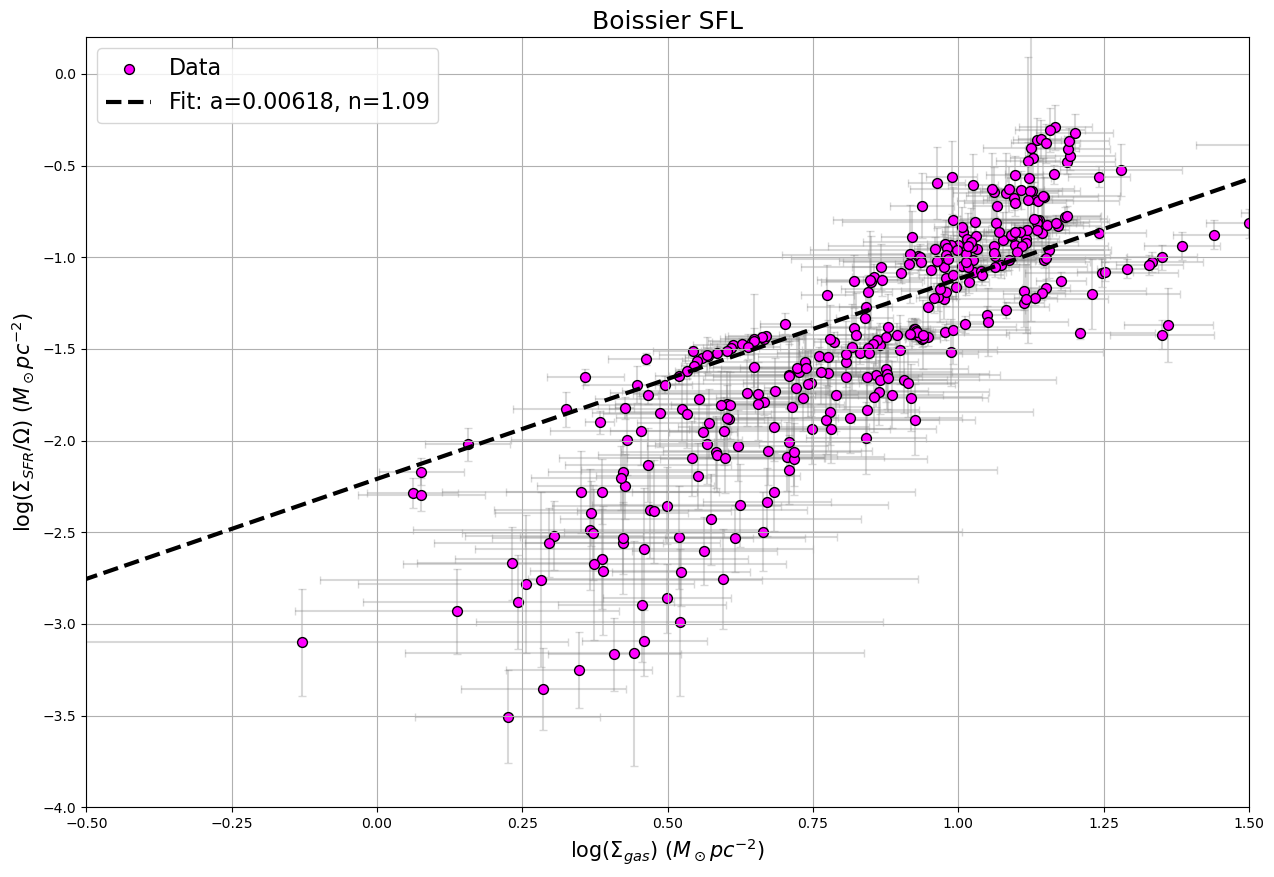

In [21]:
fig = figure(figsize=(15,10), facecolor='w')
frame = fig.add_subplot(1,1,1)
frame.scatter(log_sgas, log_y, color="magenta", edgecolor='k', s=50, label="Data")
frame.errorbar(log_sgas, log_y, xerr=log_esgas, yerr=log_ey, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
frame.plot(np.linspace(-1, 2, 50), lin2(np.linspace(-1, 2, 50), a_2, b_2), color="k", lw=3, ls="dashed", label=f"Fit: a={10**b_2:.5f}, n={a_2:.2f}")
#frame.set_xscale('log')
#frame.set_yscale('log')
frame.set_xlim(-0.5, 1.5)
frame.set_ylim(-4, 0.2)
frame.set_title(r"Boissier SFL", fontsize = 18)
frame.set_xlabel(r"log$(\Sigma_{gas})$ $(M_\odot pc^{-2})$", fontsize = 15)
frame.set_ylabel(r"log$(\Sigma_{SFR}/\Omega)$ $(M_\odot pc^{-2})$", fontsize = 15)
frame.legend(prop={'size': 16})
frame.grid()
show()

Number of data points: 343
-------------------------
PEARSON'S TEST
Correlation coefficient: 0.8368; p-value 3.05e-91
-------------------------
SPEARMAN'S TEST
Correlation coefficient: 0.8884; p-value 2.331e-117
-------------------------
KENDALL'S TEST
Correlation coefficient: 0.7; p-value 2.302e-83
-------------------------
Running MCMC with 128 cores. Please wait...
Converged after 3800 iterations in 21 seconds
Mean acceptance fraction: 0.643
-------------------------
Maximum likelihood (ML) value: 117.7
Slope (ML, median, upper error, lower error): 2.13; 2.141; +0.09728, -0.08917
Intercept (ML, median, upper error, lower error): -3.232; -3.241; +0.08541; -0.09082
Intrinsic scatter (ML, median, upper error, lower error): 0.1383; 0.1386; +0.007831; -0.007123
ML observed scatter (vertical): 0.3797
ML observed scatter (orthogonal): 0.1614
*** NB medians and errors only meaningful for unimodal posteriors. Check the corner plot! ***
-------------------------


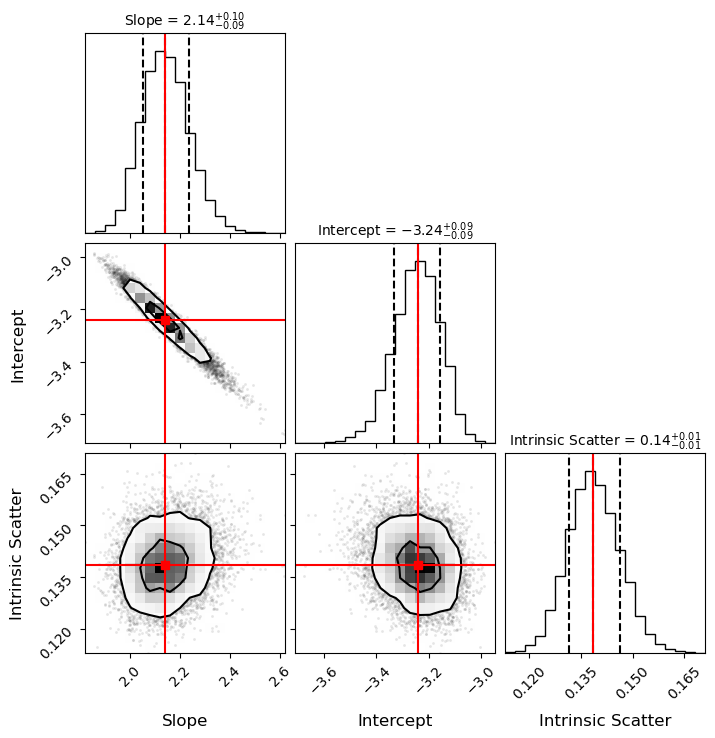

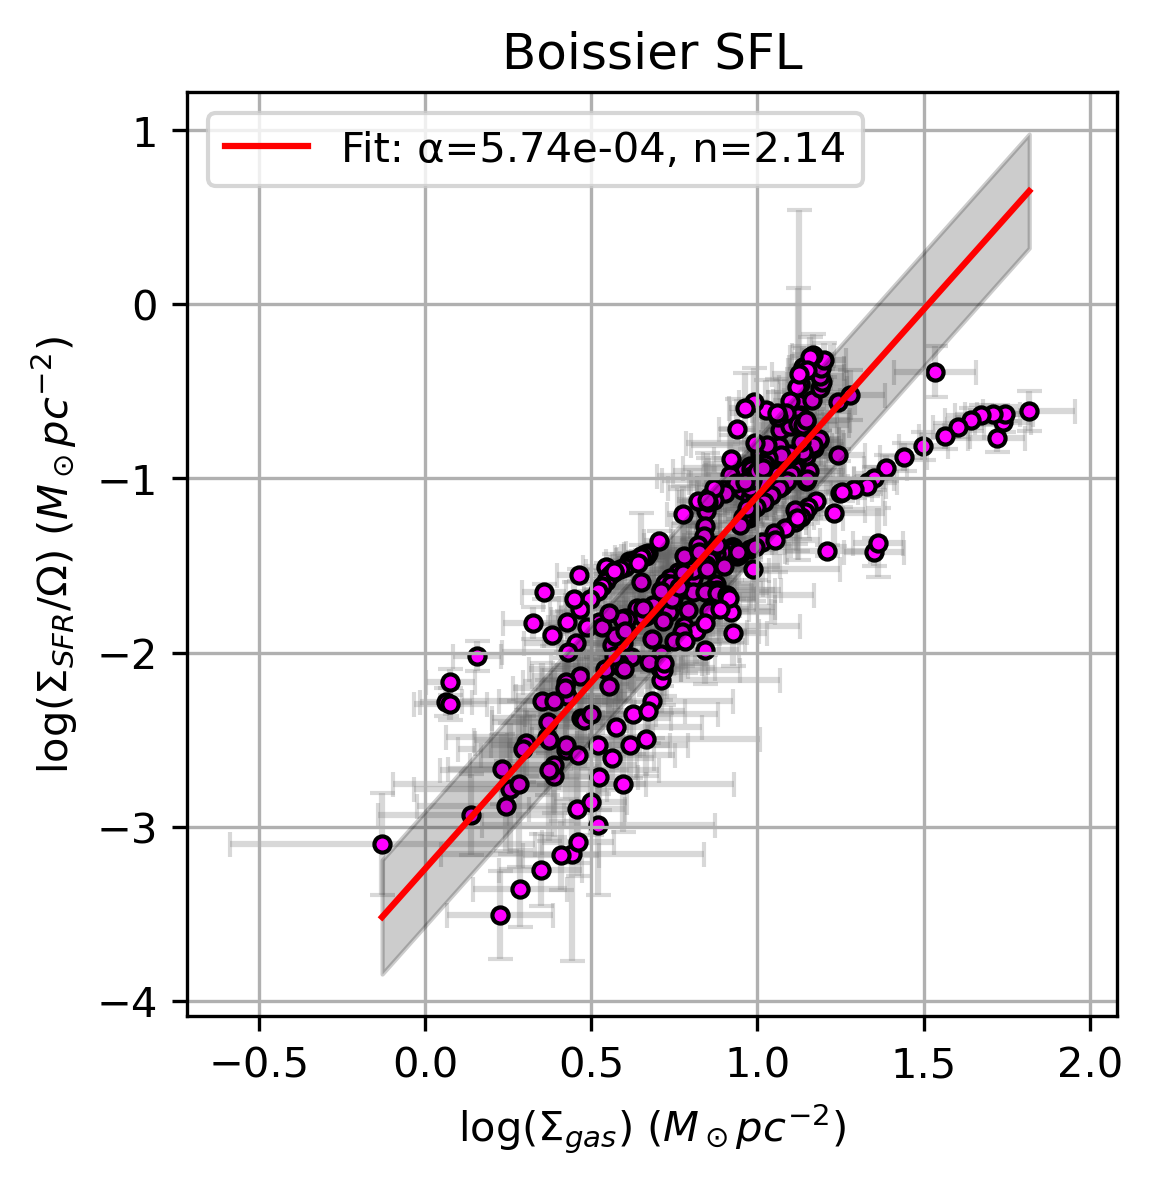

In [22]:
a, b, s, sobs = blf.BayesLineFit(log_sgas, log_y, log_esgas, log_ey, outfile_chain=None, 
                                 outfile_bestfit=None, outplot_convergence=None, plotpdf=False,
                                plot_title="boissier")

# Kennicutt-Schmidt SFL fitting

In [23]:
# remove values of masked_KSL_only_sigma_gas<0.15 since it is causing issues in the log scale plot

min_index = np.where(masked_KSL_only_sigma_gas < 0.15)[0]
masked_KSL_only_sigma_gas_mod = np.delete(masked_KSL_only_sigma_gas, min_index)
masked_KSL_only_sigma_gas_err_mod = np.delete(masked_KSL_only_sigma_gas_err, min_index)
masked_KSL_only_sigma_sfr_mod = np.delete(masked_KSL_only_sigma_sfr, min_index)
masked_KSL_only_sigma_sfr_err_mod = np.delete(masked_KSL_only_sigma_sfr_err, min_index)

In [24]:
log_sfr = np.log10(masked_sigma_sfr_sesfl*1e9)
log_esfr = (1/np.log(10))*(masked_sigma_sfr_err_sesfl/masked_sigma_sfr_sesfl)

log_sfr_KSL = np.log10(masked_KSL_only_sigma_sfr_mod*1e9)
log_esfr_KSL = (1/np.log(10))*(masked_KSL_only_sigma_sfr_err_mod/masked_KSL_only_sigma_sfr_mod)

log_sgas_KSL = np.log10(masked_KSL_only_sigma_gas_mod)
log_esgas_KSL = (1/np.log(10))*(masked_KSL_only_sigma_gas_err_mod/masked_KSL_only_sigma_gas_mod)

In [25]:
popt, pcov = curve_fit(lin2, log_sgas_KSL, log_sfr_KSL, p0=[4, -4])
a_ksl, b_ksl = popt
#print(a_ksl, b_ksl)
print(f"a = {10**b_ksl}, n = {a_ksl}")

a = 0.015155843199626963, n = 2.0983916274866137


Number of data points: 513
-------------------------
PEARSON'S TEST
Correlation coefficient: 0.7923; p-value 9.865e-112
-------------------------
SPEARMAN'S TEST
Correlation coefficient: 0.8474; p-value 1.354e-142
-------------------------
KENDALL'S TEST
Correlation coefficient: 0.6585; p-value 4.895e-110
-------------------------
Running MCMC with 128 cores. Please wait...


Converged after 3600 iterations in 21 seconds
Mean acceptance fraction: 0.646
-------------------------
Maximum likelihood (ML) value: 155.3
Slope (ML, median, upper error, lower error): 3.249; 3.254; +0.1269, -0.1194
Intercept (ML, median, upper error, lower error): -2.797; -2.8; +0.107; -0.1146
Intrinsic scatter (ML, median, upper error, lower error): 0.1543; 0.1547; +0.006148; -0.005834
ML observed scatter (vertical): 0.587
ML observed scatter (orthogonal): 0.1727
*** NB medians and errors only meaningful for unimodal posteriors. Check the corner plot! ***
-------------------------


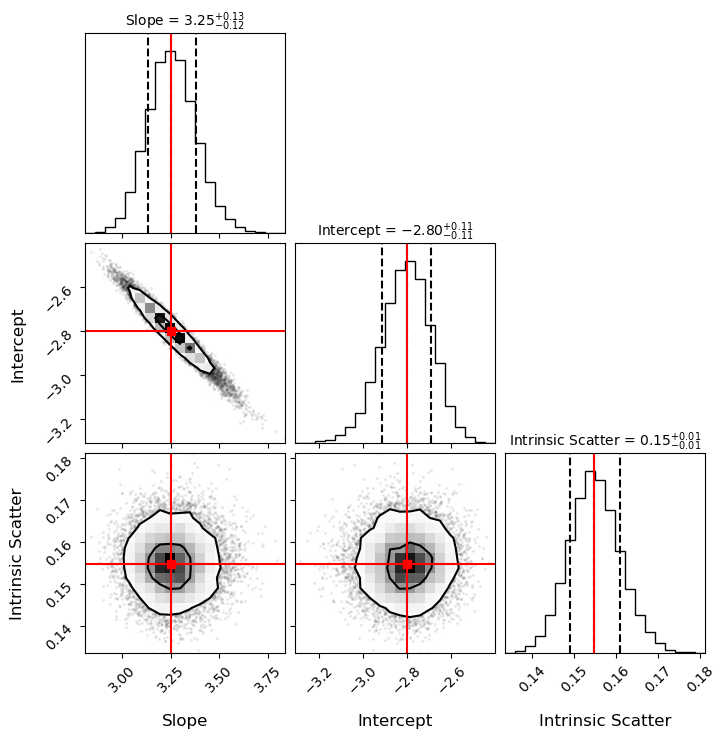

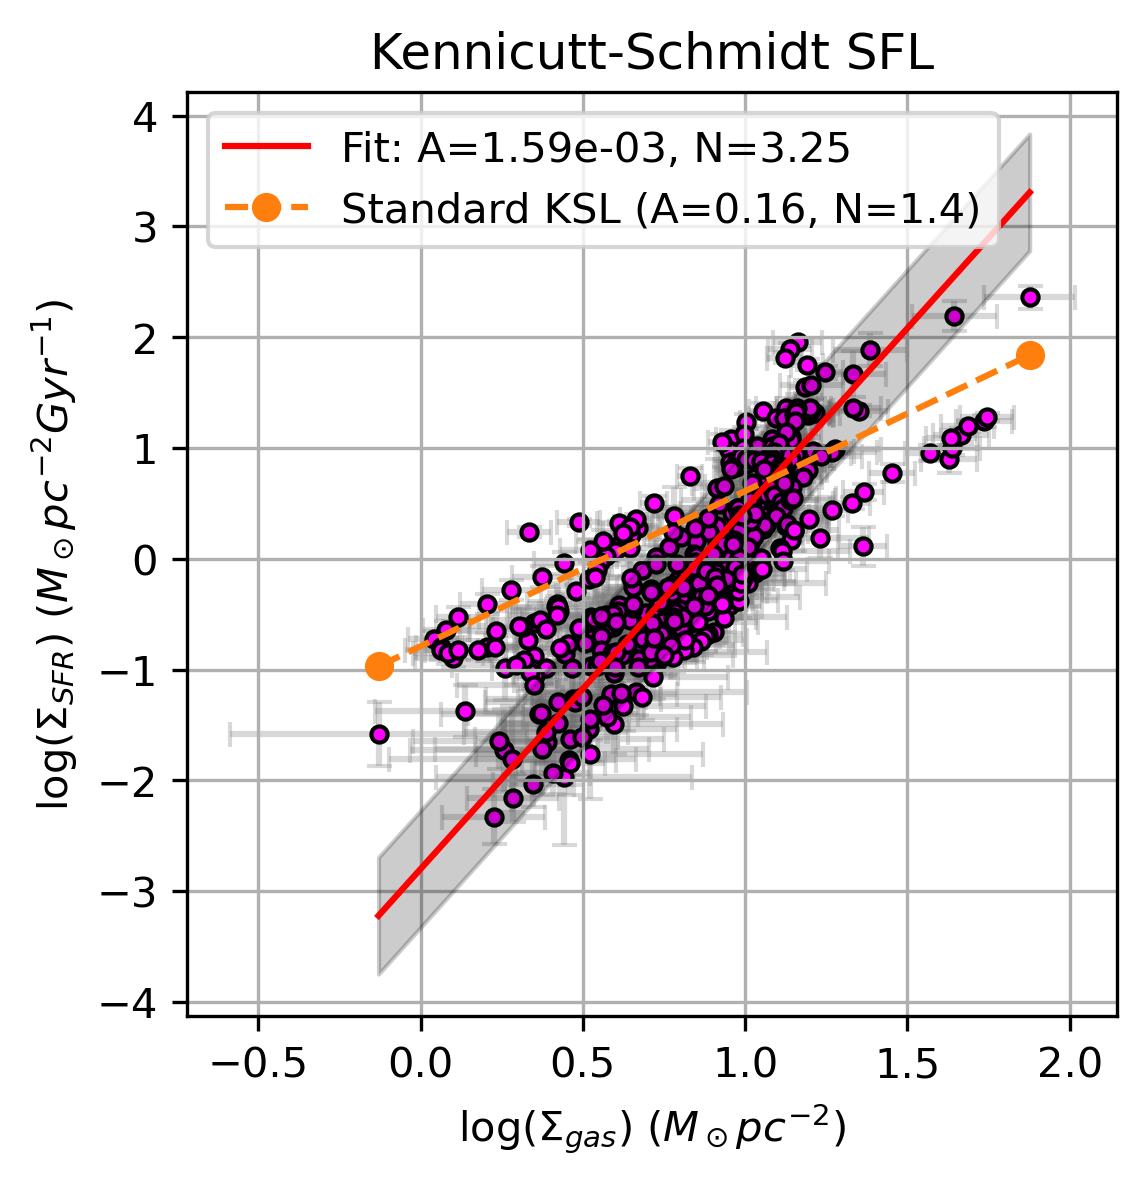

In [26]:
a, b, s, sobs = blf.BayesLineFit(log_sgas_KSL, log_sfr_KSL, log_esgas_KSL, log_esfr_KSL, outfile_chain=None, 
                                 outfile_bestfit=None, outplot_convergence=None, plotpdf=False,
                                plot_title="kennicutt")

In [27]:
#what galaxies are in log_sgas
masked_indices = np.where(mask)[0]
logged_galaxies = sfrd_on_rot["gal"].to_numpy(dtype=str)[masked_indices]
unique_logged_galaxies = np.unique(logged_galaxies)
print(unique_logged_galaxies)

['DDO101' 'DDO126' 'DDO133' 'DDO168' 'DDO47' 'DDO50' 'DDO52' 'DDO87'
 'NGC0925' 'NGC2366' 'NGC2403' 'NGC2841' 'NGC2976' 'NGC3198' 'NGC4736'
 'NGC5055' 'NGC6946' 'NGC7331' 'WLM']


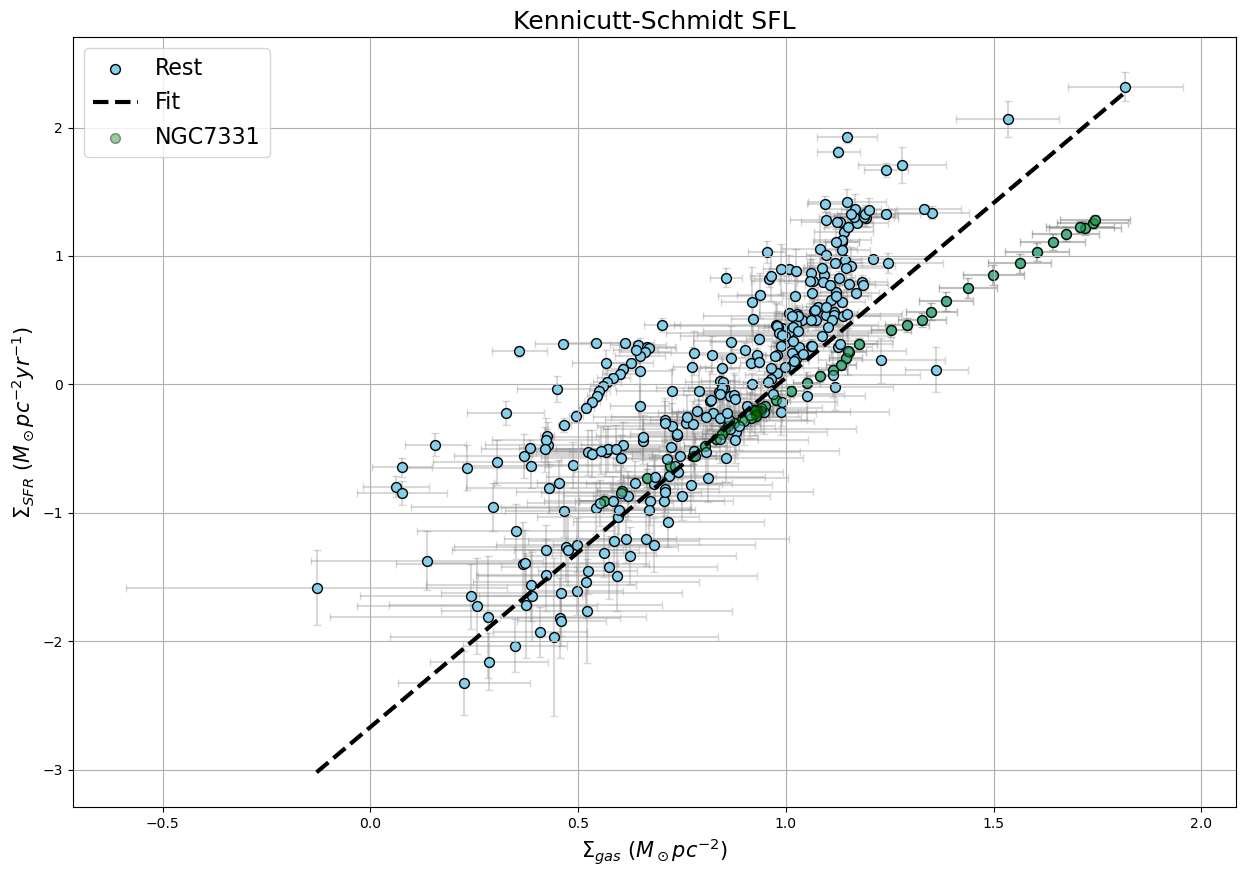

In [28]:
# show KSL with NGC 7331 (from new interpolated file!!) data colored with another color
# the data must come from sfrd_on_rot
NGC7331_data = sfrd_on_rot[sfrd_on_rot["gal"] == "NGC7331"]
NGC7331_sgas = (NGC7331_data["hi_l08(Msun/pc^2)"].to_numpy(float) + NGC7331_data["h2_f16_at_rl08(Msun/pc^2)"].to_numpy(float))
NGC7331_esgas = np.sqrt(NGC7331_data["hi_err_l08(Msun/pc^2)"].to_numpy(float)**2 + NGC7331_data["h2_err_f16_at_rl08(Msun/pc^2)"].to_numpy(float)**2)
NGC7331_ssfr = NGC7331_data["sfrd_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(float)*1e-6 # Msun/yr/kpc^2 to Msun/yr/pc^2
NGC7331_essfr = NGC7331_data["sfrd_err_l08(1e-4*Msun/yr/kpc^2)"].to_numpy(float)*1e-6

# convert NGC7331 data in the same way as log_sgas and log_sfr
log_NGC7331_sgas = np.log10(NGC7331_sgas)
log_NGC7331_esgas = (1/np.log(10))*(NGC7331_esgas/NGC7331_sgas)


log_NGC7331_ssfr = np.log10(NGC7331_ssfr*1e9)
log_NGC7331_essfr = (1/np.log(10))*(NGC7331_essfr/NGC7331_ssfr)

# function to fit linear line in log-log space
def fit_log(x, a, n):
    return np.log10(a) + n*x

fig = figure(figsize=(15,10), facecolor='w')
frame = fig.add_subplot(1,1,1)
frame.scatter(log_sgas, log_sfr, color="skyblue", edgecolor='k', s=50, label="Rest")
frame.errorbar(log_sgas, log_sfr, xerr=log_esgas, yerr=log_esfr, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
frame.plot(np.linspace(np.min(log_sgas), np.max(log_sgas), 10), fit_log(np.linspace(np.min(log_sgas), np.max(log_sgas), 10), 2.15e-3, 2.72), color="k", lw=3, ls="dashed", label="Fit")
frame.scatter(log_NGC7331_sgas, log_NGC7331_ssfr, color="green", edgecolor='k', s=50, alpha=0.4, label="NGC7331")
frame.errorbar(log_NGC7331_sgas, log_NGC7331_ssfr, xerr=log_NGC7331_esgas, yerr=log_NGC7331_essfr, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
frame.set_title(r"Kennicutt-Schmidt SFL", fontsize = 18)
frame.set_xlabel(r"$\Sigma_{gas}$ $(M_\odot pc^{-2})$", fontsize = 15)
frame.set_ylabel(r"$\Sigma_{SFR}$ $(M_\odot pc^{-2} yr^{-1})$", fontsize = 15)
frame.legend(prop={'size': 16})
frame.grid()
show()

1.0929879735931065


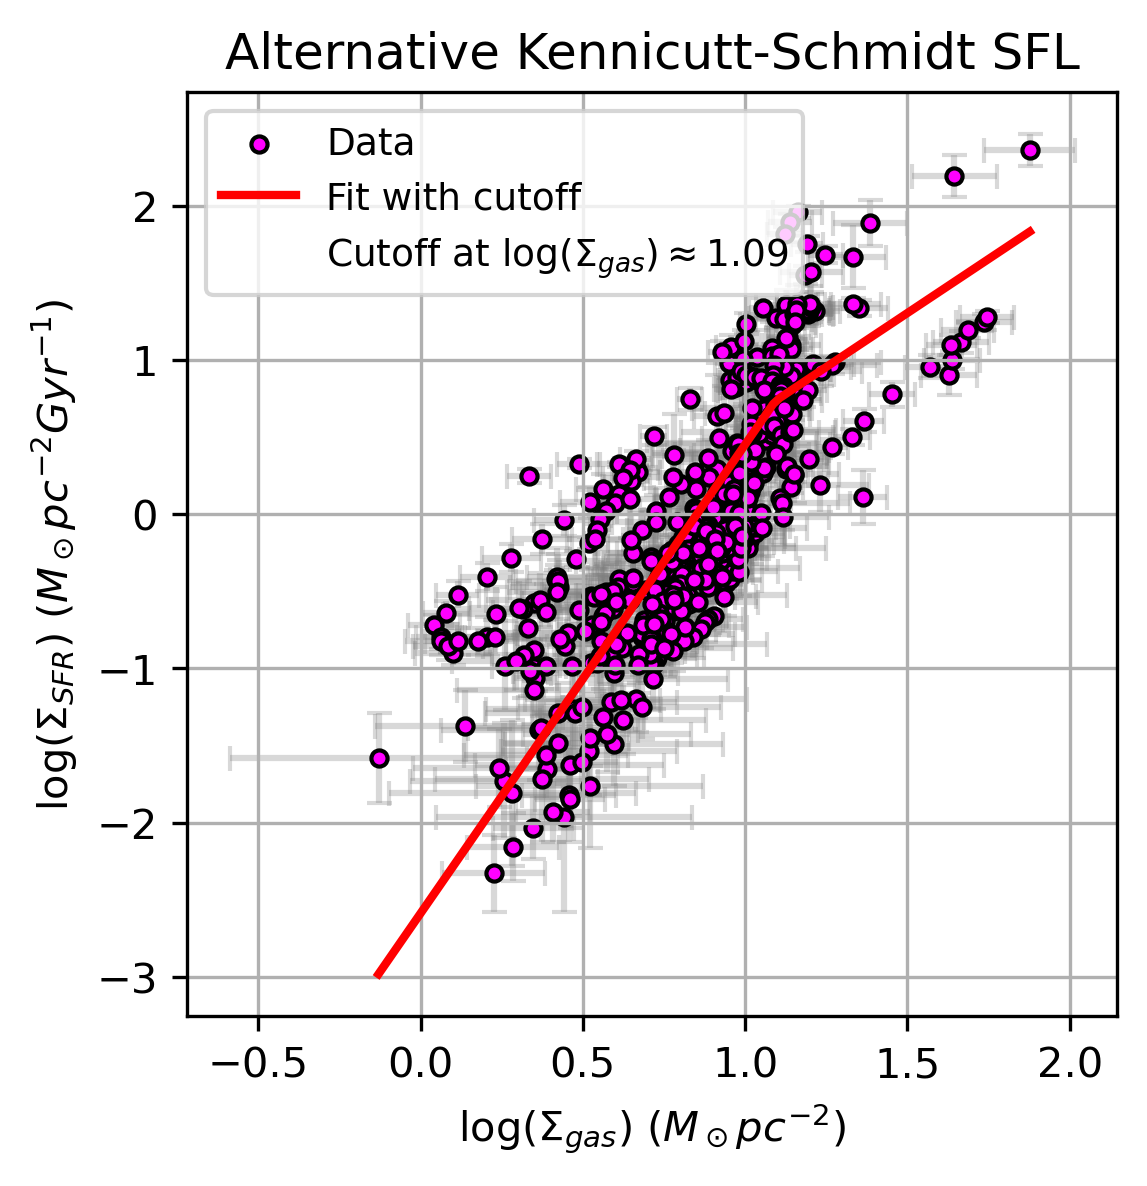

In [29]:
def new_SFL(x, m_new, b_new, x_cut=1.02391, m_old=1.4):
    # follow new KSL until x=1, then follow old KSL. Need to find intercept so both are equal at x_cut
    b_old = b_new + (m_new - m_old) * x_cut

    y = m_new * x + b_new
    mask = x > x_cut
    y[mask] = m_old * x[mask] + b_old
    return y

def intersection_x(m1, b1, m2, b2):
    return (b2 - b1)/(m1 - m2)

xii = np.linspace(np.min(log_sgas_KSL), np.max(log_sgas_KSL), 100)

inters = intersection_x(3.04, np.log10(2.58e-3), 1.4, np.log10(0.16))
print(inters)

fig = figure(figsize=(4,4), dpi=300, facecolor='w')
frame = fig.add_subplot(1,1,1)
frame.scatter(log_sgas_KSL, log_sfr_KSL, color="magenta", edgecolor='k', linewidth=1, s=15, zorder=1, label="Data")
frame.errorbar(log_sgas_KSL, log_sfr_KSL, xerr=log_esgas_KSL, yerr=log_esfr_KSL, fmt = ' ', ecolor = 'grey', capsize = 3, alpha=0.3, zorder=0)
#frame.plot(np.linspace(-0.5, 1.5, 2), lin2(np.linspace(-0.5, 1.5, 2), 1.4, np.log10(0.16)), "--o", zorder=4, label=f"Standard KSL")
frame.plot(xii, new_SFL(xii, 3.04, np.log10(2.58e-3), x_cut=inters), lw=2, color="r", zorder=4, label=f"Fit with cutoff")
frame.plot([], [], ' ', label=r"Cutoff at log$(\Sigma_{{gas}})\approx ${:.2f}".format(inters))
frame.set_title(r"Alternative Kennicutt-Schmidt SFL")
frame.set_xlabel(r"log$(\Sigma_{gas})$ $(M_\odot pc^{-2})$")
frame.set_ylabel(r"log$(\Sigma_{SFR})$ $(M_\odot pc^{-2} Gyr^{-1})$")
frame.legend(prop={'size': 9})
frame.grid()
show()